# Восканян Юрий, КИ22-17/2Б
### Программная реализация рекуррентной нейронной сети

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from keras_tuner import HyperModel, RandomSearch
import keras_tuner as kt
import pandas as pd

2025-04-29 23:28:33.060598: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-29 23:28:35.398553: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-29 23:28:36.267099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745944117.065011    6330 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745944117.248249    6330 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745944119.016229    6330 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Подготовка данных

In [ ]:
def get_train_data(train_name: str) -> list[list[float]]:
    with open(f'{os.getcwd()}/datas/train/{train_name}.txt') as file:
        datas = file.readlines()
        datas = list(map(lambda x: x.strip(), datas))
        datas = list(map(lambda x: x.replace('\n', ''), datas))
        datas = list(map(lambda x: x.split(), datas))

        return datas

In [ ]:
X_train = get_train_data('X_train')
X_train = list(map(lambda x: [float(i) for i in x], X_train))

y_train = get_train_data('y_train')
y_train = list(map(lambda x: int(x[0]), y_train))

In [ ]:
def get_test_data(test_name: str) -> list[list[float]]:
    with open(f'{os.getcwd()}/datas/test/{test_name}.txt') as file:
        datas = file.readlines()
        datas = list(map(lambda x: x.strip(), datas))
        datas = list(map(lambda x: x.replace('\n', ''), datas))
        datas = list(map(lambda x: x.split(), datas))

        return datas

In [ ]:
X_test = get_test_data('X_test')
X_test = list(map(lambda x: [float(i) for i in x], X_test))

y_test = get_test_data('y_test')
y_test = list(map(lambda x: int(x[0]), y_test))

In [ ]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train) 
y_test = np.array(y_test)  
X_train = np.transpose(X_train, (1, 2, 0))
X_test = np.transpose(X_test, (1, 2, 0))

In [ ]:
X_train.shape

In [ ]:
X_train = tf.convert_to_tensor(X_train)
X_test = tf.convert_to_tensor(X_test) 
y_train = tf.convert_to_tensor(y_train)
y_test = tf.convert_to_tensor(y_test) 

In [ ]:
SIGNALS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

In [ ]:
def _read_csv(filename):
    return pd.read_csv(filename, delim_whitespace=True, header=None)


def load_signals(subset):
    signals_data = []

    for signal in SIGNALS:
        filename = f'datas/{subset}/Inertial Signals/{signal}_{subset}.txt'
        signals_data.append(
            _read_csv(filename).to_numpy()
        )

    return np.transpose(signals_data, (1, 2, 0))

def load_y(subset):
    filename = f'datas/{subset}/y_{subset}.txt'
    y = _read_csv(filename)[0]

    return pd.get_dummies(y).to_numpy()

def load_data():
    X_train, X_test = load_signals('train'), load_signals('test')
    y_train, y_test = load_y('train'), load_y('test')

    return X_train, X_test, y_train, y_test

def plot_train_val_accuracy_loss(history):
    plt.figure(figsize=(10, 10))

    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Loss')

    plt.subplot(2, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.title('Accuracy')

In [5]:
def _count_classes(y):
    return len(set([tuple(category) for category in y]))

X_train, X_test, Y_train, Y_test = load_data()
timesteps = len(X_train[0])
input_dim = len(X_train[0][0])
n_classes = _count_classes(Y_train)

/tmp/ipykernel_6330/265407189.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_6330/265407189.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_6330/265407189.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_6330/265407189.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_6330/

In [6]:
def plot_history(history):
    history_dict = history.history
    loss = history_dict['loss']
    val_loss = history_dict.get('val_loss')
    accuracy = history_dict.get('accuracy')
    val_accuracy = history_dict.get('val_accuracy')
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    if accuracy:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, accuracy, 'bo-', label='Training accuracy')
        if val_accuracy:
            plt.plot(epochs, val_accuracy, 'ro-', label='Validation accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

    plt.show()

# Создание моделей
### Classic RNN

In [16]:
print(f'{X_train.shape = }')
print(f'{X_test.shape = }')
print(f'{Y_train.shape = }')
print(f'{Y_test.shape = }')

X_train.shape = (7352, 128, 9)
X_test.shape = (2947, 128, 9)
Y_train.shape = (7352, 6)
Y_test.shape = (2947, 6)


In [ ]:
def build_model(hp):
    model = keras.Sequential()
    
    num_layers = hp.Int('num_layers', 1, 3)
    
    for i in range(num_layers):
        units = hp.Int(f'units_{i}', min_value=32, max_value=256, step=32)
        
        return_sequences = i < num_layers - 1
        
        model.add(keras.layers.SimpleRNN(
            units=units,
            input_shape=(128, 9) if i == 0 else None,
            activation='relu',
            return_sequences=return_sequences
        ))
    
    model.add(keras.layers.Dense(6, activation='softmax'))
    
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd'])
    learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [24]:
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='rnn_tuning',
    project_name='rnn_hyperparams'
)

/home/ammrr/Рабочий стол/NN_4/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
tuner.search(
    X_train, Y_train,
    epochs=15,
    validation_data=(X_test, Y_test),
    batch_size=64
)

Trial 20 Complete [00h 00m 58s]
val_accuracy: 0.7522904872894287

Best val_accuracy So Far: 0.9100780487060547
Total elapsed time: 00h 24m 43s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparams = tuner.get_best_hyperparameters()[0]

print(f"Лучшие гиперпараметры: {best_hyperparams.values}")

Лучшие гиперпараметры: {'num_layers': 2, 'units_0': 160, 'optimizer': 'rmsprop', 'learning_rate': 0.001, 'units_1': 96, 'units_2': 192}


/home/ammrr/Рабочий стол/NN_4/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/ammrr/Рабочий стол/NN_4/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [28]:
history = best_model.fit(
    X_train, Y_train,
    epochs=10, batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9361 - loss: 3258.7329 - val_accuracy: 0.8829 - val_loss: 1.5921
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9433 - loss: 0.4842 - val_accuracy: 0.8819 - val_loss: 0.5992
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9502 - loss: 0.2277 - val_accuracy: 0.8972 - val_loss: 0.7628
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9504 - loss: 0.1540 - val_accuracy: 0.8955 - val_loss: 0.5296
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9501 - loss: 45.8201 - val_accuracy: 0.9067 - val_loss: 1.0840
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9533 - loss: 1.6173 - val_accuracy: 0.8605 - val_loss: 0.6251
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9478 - loss: 0.3237 - val_accuracy: 0.7367 - val_loss: 575.9037
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9457 - loss: 30.4057 - v

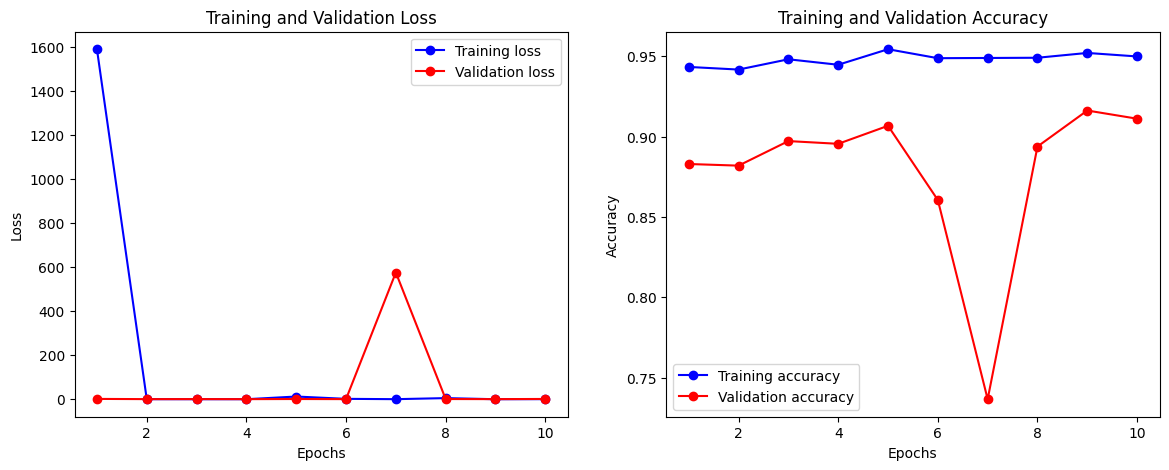

In [30]:
plot_history(history)

# LSTM
Forget Gate  
Input Gate  
Output Gate   

In [ ]:
def build_model(hp):
    model = keras.Sequential()
    
    num_layers = hp.Int('num_layers', 1, 3)
    
    for i in range(num_layers):
        units = hp.Int(f'units_{i}', min_value=32, max_value=256, step=32)
        
        return_sequences = i < num_layers - 1
        
        model.add(keras.layers.LSTM(
            units=units,
            input_shape=(128, 9) if i == 0 else None,
            activation='relu',
            return_sequences=return_sequences
        ))
    
    model.add(keras.layers.Dense(6, activation='softmax'))
    
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd'])
    learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [42]:
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=7,
    executions_per_trial=1,
    directory='rnn_tuning',
    project_name='rnn_hyperparams'
)

/home/ammrr/Рабочий стол/NN_4/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
tuner.search(
    X_train, Y_train,
    epochs=15,
    validation_data=(X_test, Y_test),
    batch_size=64
)

Trial 7 Complete [00h 02m 43s]
val_accuracy: 0.1425178200006485

Best val_accuracy So Far: 0.5622667074203491
Total elapsed time: 00h 19m 23s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparams = tuner.get_best_hyperparameters()[0]

print(f"Лучшие гиперпараметры: {best_hyperparams.values}")

Лучшие гиперпараметры: {'num_layers': 1, 'units_0': 128, 'optimizer': 'rmsprop', 'learning_rate': 0.0001, 'units_1': 32, 'units_2': 160}


/home/ammrr/Рабочий стол/NN_4/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/ammrr/Рабочий стол/NN_4/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 7 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [45]:
history = best_model.fit(
    X_train, Y_train,
    epochs=10, batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.5418 - loss: 228.8849 - val_accuracy: 0.5528 - val_loss: 2.1098
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5714 - loss: 5.8367 - val_accuracy: 0.5287 - val_loss: 1.3188
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.6033 - loss: 104.5511 - val_accuracy: 0.5490 - val_loss: 9.5176
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.5606 - loss: 311.5780 - val_accuracy: 0.4988 - val_loss: 1474.6140
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5354 - loss: 2341.9382 - val_accuracy: 0.4964 - val_loss: 1.3000
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.5544 - loss: 20083.2383 - val_accuracy: 0.3912 - val_loss: 135515.7812
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.3713 - loss: 3192226.7500 - val_accuracy: 0.3845 - val_loss: 1432441.6250
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - a

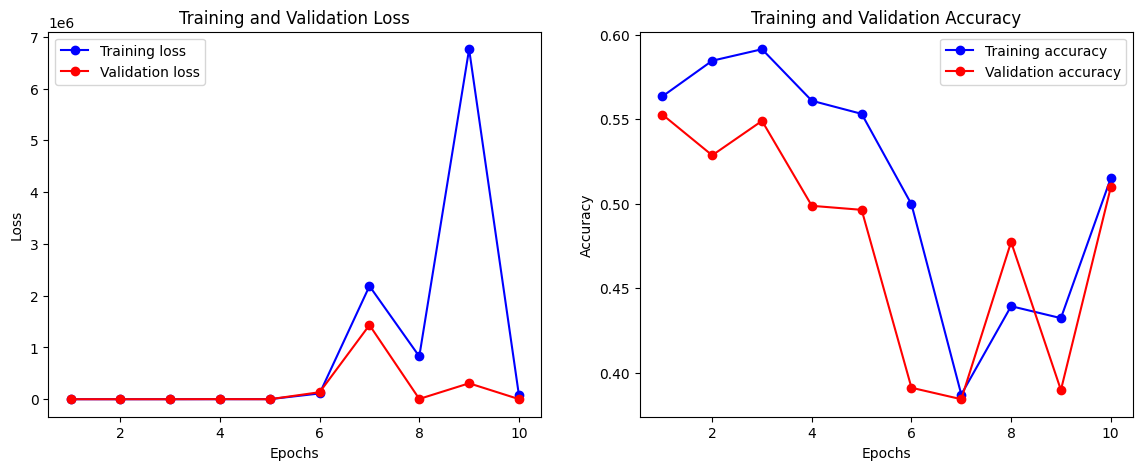

In [46]:
plot_history(history)

# GRU
Reset Gate     
Update Gate  

In [ ]:
def build_gru_model(hp):
    model = keras.Sequential()
    
    num_layers = hp.Int('num_layers', 1, 3)
    
    for i in range(num_layers):
        units = hp.Int(f'gru_units_{i}', min_value=32, max_value=256, step=32)
        
        return_sequences = i < num_layers - 1
        
        model.add(keras.layers.GRU(
            units=units,
            input_shape=(128, 9) if i == 0 else None,
            activation='tanh',
            recurrent_activation='sigmoid',
            return_sequences=return_sequences,
            dropout=hp.Float(f'dropout_{i}', 0.0, 0.3, step=0.1),
            recurrent_dropout=hp.Float(f'recurrent_dropout_{i}', 0.0, 0.2, step=0.1)
        ))
    
    model.add(keras.layers.BatchNormalization())
    
    model.add(keras.layers.Dense(
        6, 
        activation='softmax',
        kernel_regularizer=keras.regularizers.l2(hp.Float('l2_reg', 1e-4, 1e-2))
    ))
    
    optimizer = hp.Choice('optimizer', ['adam', 'nadam', 'rmsprop'])
    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'nadam':
        opt = keras.optimizers.Nadam(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [48]:
tuner = RandomSearch(
    build_gru_model,
    objective='val_accuracy',
    max_trials=7,
    executions_per_trial=1,
    directory='rnn_tuning',
    project_name='rnn_hyperparams'
)

In [49]:
tuner.search(
    X_train, Y_train,
    epochs=15,
    validation_data=(X_test, Y_test),
    batch_size=64
)

Trial 7 Complete [00h 02m 45s]
val_accuracy: 0.9131320118904114

Best val_accuracy So Far: 0.9287410974502563
Total elapsed time: 00h 22m 41s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparams = tuner.get_best_hyperparameters()[0]

print(f"Лучшие гиперпараметры: {best_hyperparams.values}")

Лучшие гиперпараметры: {'num_layers': 2, 'gru_units_0': 256, 'dropout_0': 0.2, 'recurrent_dropout_0': 0.0, 'l2_reg': 0.0024969575623737055, 'optimizer': 'nadam', 'learning_rate': 0.0023385968908569412, 'gru_units_1': 32, 'dropout_1': 0.0, 'recurrent_dropout_1': 0.0}


/home/ammrr/Рабочий стол/NN_4/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 23 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [51]:
history = best_model.fit(
    X_train, Y_train,
    epochs=10, batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.8974 - loss: 0.2465 - val_accuracy: 0.8795 - val_loss: 0.3078
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.8973 - loss: 0.2481 - val_accuracy: 0.8724 - val_loss: 0.2772
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.8342 - loss: 0.4194 - val_accuracy: 0.8894 - val_loss: 0.3181
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.8907 - loss: 0.2597 - val_accuracy: 0.9006 - val_loss: 0.2711
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.9002 - loss: 0.2323 - val_accuracy: 0.8799 - val_loss: 0.2907
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.9058 - loss: 0.2188 - val_accuracy: 0.8860 - val_loss: 0.2729
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.9024 - loss: 0.2091 - val_accuracy: 0.9226 - val_loss: 0.2052
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.9022 - loss: 0.2124 - 

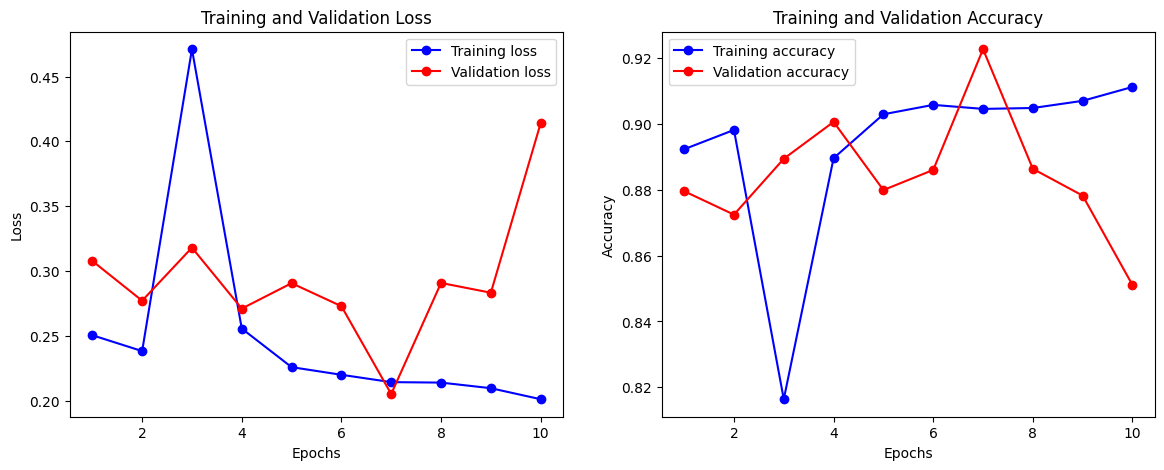

In [53]:
plot_history(history)

# Bidirectional RNN

In [ ]:
def build_bidirectional_gru_model(hp):
    model = keras.Sequential()
    
    num_layers = hp.Int('num_layers', 1, 3)
    
    for i in range(num_layers):
        units = hp.Int(f'gru_units_{i}', min_value=32, max_value=256, step=32)
        
        return_sequences = i < num_layers - 1
        
        model.add(
            layers.Bidirectional(
                layers.GRU(
                    units=units,
                    input_shape=(128, 9) if i == 0 else None,
                    activation='tanh',
                    recurrent_activation='sigmoid',
                    return_sequences=return_sequences,
                    dropout=hp.Float(f'dropout_{i}', 0.0, 0.3, step=0.1),
                    recurrent_dropout=hp.Float(f'recurrent_dropout_{i}', 0.0, 0.2, step=0.1)
                ),
                merge_mode=hp.Choice(f'merge_mode_{i}', ['concat', 'sum'])
            )
        )
    
    model.add(layers.BatchNormalization())
    
    model.add(
        Dense(
            6, 
            activation='softmax',
            kernel_regularizer=keras.regularizers.l2(hp.Float('l2_reg', 1e-4, 1e-2))
        )
    )
    
    optimizer = hp.Choice('optimizer', ['adam', 'nadam', 'rmsprop'])
    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'nadam':
        opt = keras.optimizers.Nadam(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [9]:
tuner = RandomSearch(
    build_bidirectional_gru_model,
    objective='val_accuracy',
    max_trials=7,
    executions_per_trial=1,
    directory='rnn_tuning',
    project_name='rnn_hyperparams'
)

E0000 00:00:1745944701.912905    6330 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1745944701.913695    6330 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/ammrr/Рабочий стол/NN_4/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
tuner.search(
    X_train, Y_train,
    epochs=15,
    validation_data=(X_test, Y_test),
    batch_size=64
)

Trial 7 Complete [00h 14m 02s]
val_accuracy: 0.9280624389648438

Best val_accuracy So Far: 0.937224268913269
Total elapsed time: 01h 05m 06s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparams = tuner.get_best_hyperparameters()[0]

print(f"Лучшие гиперпараметры: {best_hyperparams.values}")

Лучшие гиперпараметры: {'num_layers': 1, 'gru_units_0': 128, 'dropout_0': 0.0, 'recurrent_dropout_0': 0.1, 'merge_mode_0': 'sum', 'l2_reg': 0.0008906090660339674, 'optimizer': 'rmsprop', 'learning_rate': 0.0025693372526793524}


/home/ammrr/Рабочий стол/NN_4/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [12]:
history = best_model.fit(
    X_train, Y_train,
    epochs=10, batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.9414 - loss: 0.1372 - val_accuracy: 0.9009 - val_loss: 0.2888
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.9492 - loss: 0.1266 - val_accuracy: 0.9125 - val_loss: 0.2530
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.9545 - loss: 0.1155 - val_accuracy: 0.9175 - val_loss: 0.2076
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - accuracy: 0.9479 - loss: 0.1259 - val_accuracy: 0.9230 - val_loss: 0.2267
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.9560 - loss: 0.1174 - val_accuracy: 0.9298 - val_loss: 0.1912
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - accuracy: 0.9516 - loss: 0.1236 - val_accuracy: 0.9237 - val_loss: 0.2696
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.9449 - loss: 0.1339 - val_accuracy: 0.8870 - val_loss: 0.4591
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.9508 - loss: 0.1255 - 

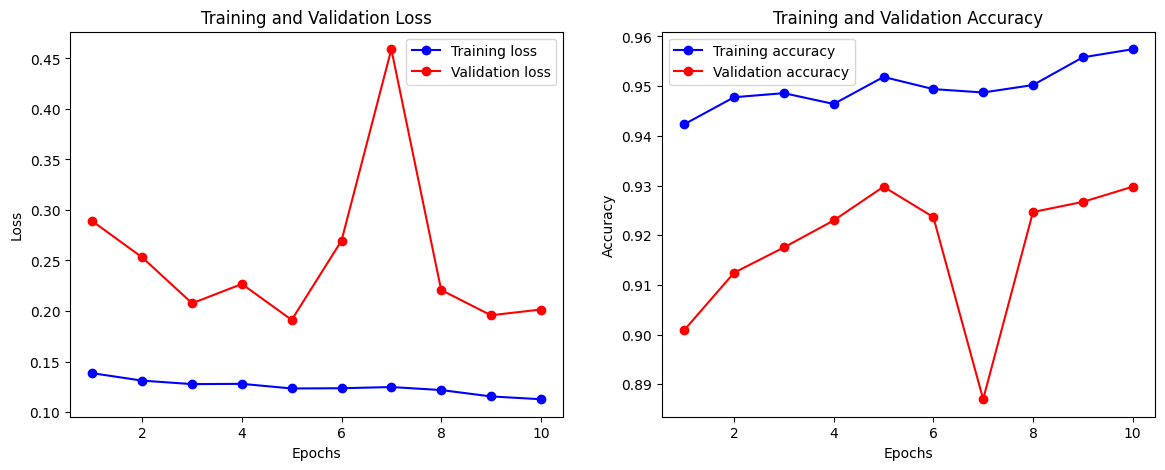

In [13]:
plot_history(history)